In [84]:
import pandas as pd
import numpy as np
from pykalman import KalmanFilter
from scipy.stats import norm
import pandas_ta as ta
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load and prepare data
asset = "bitcoin"

# Load Chainlink candle data
df_1 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/data/micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

# Load Chainlink asset data
df_2 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/data/micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

# Load Bitcoin candle data
btc_df = pd.read_csv("/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv")
btc_df['date'] = pd.to_datetime(btc_df['date'])
btc_df.set_index('date', inplace=True)

# Merge data
data = pd.merge(df_1, df_2[['total_volume', 'market_cap']], on='date', how='inner')
data.rename(columns={'total_volume': 'Volume', 'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close'}, inplace=True)
data.index.name = 'Date'


if asset != "bitcoin":
    data['close_btc'] = (data['Close'] / btc_df['close']) * 100
    data.dropna(inplace=True)

# Optional: Filter data (uncomment if needed)
data = data[data.index > '2018-01-01']

data.tail()

,Open,High,Low,Close,Volume,market_cap
Date,,,,,,
2025-02-19,95785.0,96663.0,93435.0,95496.0,2.770322e+10,1.914338e+12
2025-02-20,95614.0,96806.0,95018.0,96555.0,2.417526e+10,1.950376e+12
2025-02-21,96636.0,98758.0,96465.0,98384.0,4.247747e+10,1.906058e+12
2025-02-22,98337.0,99504.0,94909.0,96135.0,1.846442e+10,1.915260e+12
2025-02-23,95957.0,96881.0,95757.0,96564.0,1.664304e+10,1.909626e+12


In [85]:
data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)
data.tail()

,Open,High,Low,Close,Volume,market_cap,log_returns
Date,,,,,,,
2025-02-19,95785.0,96663.0,93435.0,95496.0,2.770322e+10,1.914338e+12,-0.002928
2025-02-20,95614.0,96806.0,95018.0,96555.0,2.417526e+10,1.950376e+12,0.011028
2025-02-21,96636.0,98758.0,96465.0,98384.0,4.247747e+10,1.906058e+12,0.018765
2025-02-22,98337.0,99504.0,94909.0,96135.0,1.846442e+10,1.915260e+12,-0.023125
2025-02-23,95957.0,96881.0,95757.0,96564.0,1.664304e+10,1.909626e+12,0.004453


<Axes: >

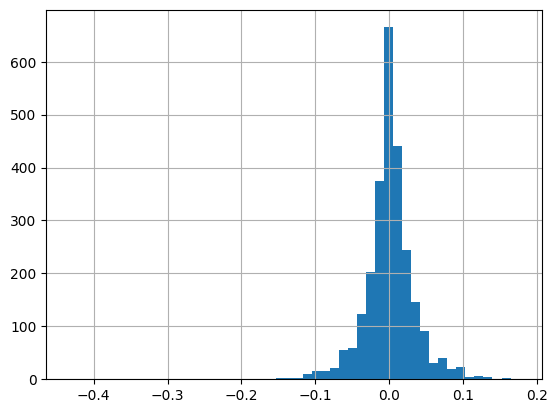

In [86]:
data['log_returns'].hist(bins=50)

## Baysian HMM 

### Conceptual Model

* Latent States: Discrete regimes (e.g., 3 states: bull, bear, sideways). These are hidden and Markovian—each depends only on the last.
* Observations: Log returns, modeled as Normal distributions per regime (mean and variance differ by regime).

### Parameters

* Transition probabilities: A 3x3 matrix (if 3 regimes), where each row sums to 1.
* Emission parameters: For each regime, a mean (μ) and standard deviation (σ) for the Normal distribution of log returns.

### Bayesian Angle

We won’t fix these parameters; we’ll give them priors and let the data update them:

* Transition probs: Dirichlet prior (encourages probabilities to sum to 1).
* Means: Normal prior (e.g., centered at 0, since returns can be positive or negative).
* Std devs: Something like an Inverse Gamma or Half-Normal prior (positive, for variance).

In [87]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
from jax import random

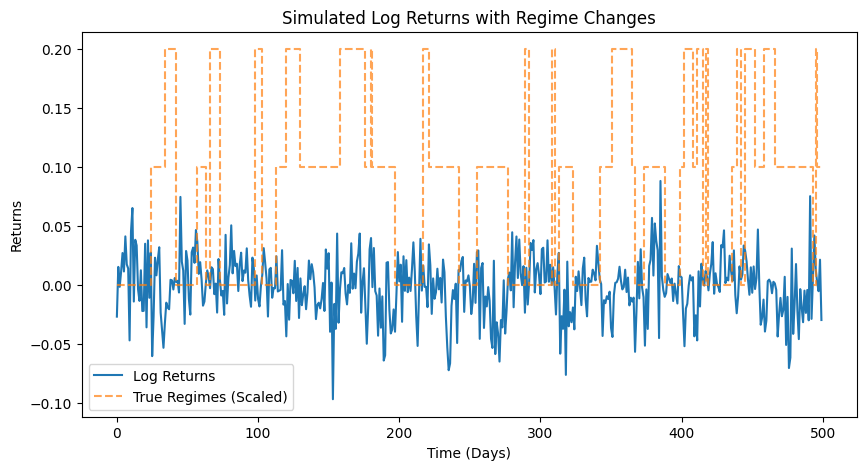

In [88]:
import jax.numpy as jnp
import jax.random as random
import jax.lax as lax
import jax.scipy.stats as stats
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

# Simulate fake returns with 3 regimes
def simulate_returns(rng_key, num_days=500):
    rng_key, key_trans, key_regime, key_emit = random.split(rng_key, 4)
    
    # Transition matrix (3 regimes, high persistence)
    trans_prob = jnp.array([
        [0.9, 0.05, 0.05],  # Stay in bull or switch
        [0.05, 0.9, 0.05],  # Stay in bear
        [0.05, 0.05, 0.9]   # Stay in sideways
    ])
    
    # Regime parameters: (mean, std dev)
    regimes = jnp.array([
        [0.01, 0.02],  # Bull: positive mean, low volatility
        [-0.01, 0.03], # Bear: negative mean, higher volatility
        [0.0, 0.015]   # Sideways: near-zero mean, low volatility
    ])
    
    states = []
    returns = []
    state = 0  # Start in bull

    for t in range(num_days):
        rng_key, key_regime, key_emit = random.split(rng_key, 3)  # Proper update
        state = dist.Categorical(trans_prob[state]).sample(key=key_regime)
        ret = dist.Normal(regimes[state, 0], regimes[state, 1]).sample(key=key_emit)
        states.append(state)
        returns.append(ret)
    
    return jnp.array(states), jnp.array(returns)

# Generate data
rng_key = random.PRNGKey(42)
num_days = 500
states, returns = simulate_returns(rng_key, num_days)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(returns, label='Log Returns', color='tab:blue')
plt.step(range(num_days), states / 10, label='True Regimes (Scaled)', color='tab:orange', linestyle='dashed', alpha=0.7)
plt.xlabel("Time (Days)")
plt.ylabel("Returns")
plt.legend()
plt.title("Simulated Log Returns with Regime Changes")
plt.show()


In [89]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
from jax import random, vmap
import jax.lax as lax  # Added for scan
from jax.scipy.special import logsumexp  # Added for logsumexp

# Define the forward algorithm
def forward_one_step(prev_log_prob, curr_return, transition_log_prob, means, stds):
    # Expand previous log probs and add transition log probs
    log_prob_tmp = jnp.expand_dims(prev_log_prob, axis=1) + transition_log_prob
    # Log likelihood of current return for each regime
    emission_log_prob = dist.Normal(means, stds).log_prob(curr_return)
    # Combine and marginalize
    log_prob = log_prob_tmp + emission_log_prob
    return logsumexp(log_prob, axis=0)  # Use jax.scipy.special.logsumexp

def forward_log_prob(returns, transition_log_prob, means, stds):
    # Initial log prob for first return
    init_log_prob = dist.Normal(means, stds).log_prob(returns[0])
    # Scan over remaining returns
    def scan_fn(log_prob, return_t):
        next_log_prob = forward_one_step(log_prob, return_t, transition_log_prob, means, stds)
        return next_log_prob, None  # No need to collect outputs
    log_probs, _ = lax.scan(scan_fn, init_log_prob, returns[1:])
    return log_probs

# Define the HMM model
def hmm_regimes(returns, num_regimes=2):
    # Priors
    transition_prob = numpyro.sample(
        "transition_prob",
        dist.Dirichlet(jnp.ones((num_regimes, num_regimes)))
    )
    means = numpyro.sample(
        "means",
        dist.Normal(0, 0.05),  # Prior for regime means
        sample_shape=(num_regimes,)
    )
    stds = numpyro.sample(
        "stds",
        dist.HalfNormal(0.05),  # Prior for regime std devs
        sample_shape=(num_regimes,)
    )
    
    # Compute marginalized log probability
    transition_log_prob = jnp.log(transition_prob)
    log_probs = forward_log_prob(returns, transition_log_prob, means, stds)
    total_log_prob = logsumexp(log_probs[-1])  # Total log prob of sequence
    numpyro.factor("forward_log_prob", total_log_prob)

def regime_probs(returns, samples, num_regimes=3):
    trans_prob = samples['transition_prob'].mean(axis=0)
    means = samples['means'].mean(axis=0)
    stds = samples['stds'].mean(axis=0)
    
    # Precompute log transition probabilities
    trans_log_prob = jnp.log(trans_prob)
    
    def log_prob_t(t, prev_log_probs):
        # Emission log probability for current return (t is now a scalar int32 in scan)
        emit = dist.Normal(means, stds).log_prob(returns[t])
        
        # Combine previous log probs with transitions and emissions
        log_prob = prev_log_probs[:, None] + trans_log_prob + emit
        return logsumexp(log_prob, axis=0), None  # Marginalize over regimes
    
    # Initial log probabilities (for t=0)
    init_log_probs = dist.Normal(means, stds).log_prob(returns[0])
    
    # Scan over time steps (starting from t=1, use int32 for indexing)
    T = len(returns)
    final_log_probs, _ = lax.scan(log_prob_t, init_log_probs, jnp.arange(1, T, dtype=jnp.int32))
    
    # Stack initial and scanned probabilities
    all_log_probs = jnp.vstack([init_log_probs[None, :], final_log_probs])
    
    # Normalize to get probabilities
    log_norm = logsumexp(all_log_probs, axis=1, keepdims=True)
    return jnp.exp(all_log_probs - log_norm)









sample: 100%|██████████| 1500/1500 [03:40<00:00,  6.80it/s, 31 steps of size 1.17e-01. acc. prob=0.91]   



                          mean       std    median      5.0%     95.0%     n_eff     r_hat
            means[0]      0.00      0.00      0.00      0.00      0.00    923.57      1.00
            means[1]     -0.00      0.00     -0.00     -0.00      0.00   1055.23      1.00
             stds[0]      0.02      0.00      0.02      0.02      0.02    334.19      1.00
             stds[1]      0.06      0.00      0.06      0.05      0.06    320.58      1.00
transition_prob[0,0]      0.81      0.03      0.81      0.76      0.86    311.28      1.00
transition_prob[0,1]      0.19      0.03      0.19      0.14      0.24    311.28      1.00
transition_prob[1,0]      0.38      0.05      0.38      0.29      0.46    286.45      1.00
transition_prob[1,1]      0.62      0.05      0.62      0.54      0.71    286.45      1.00

Number of divergences: 0


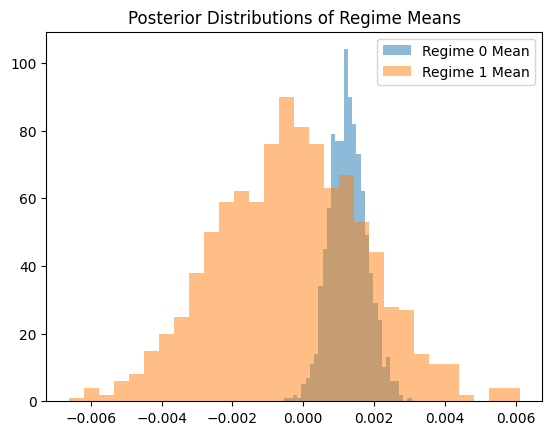

In [90]:
# Convert to JAX array
returns = jnp.array(data['log_returns'].values)

# Run inference
rng_key = random.PRNGKey(123)
kernel = NUTS(hmm_regimes)
mcmc = MCMC(kernel, num_warmup=500, num_samples=1000)
mcmc.run(rng_key, returns=returns)

# Results
mcmc.print_summary()
samples = mcmc.get_samples()

# Plot posterior means
import matplotlib.pyplot as plt
plt.hist(samples['means'][:, 0], bins=30, alpha=0.5, label='Regime 0 Mean')
plt.hist(samples['means'][:, 1], bins=30, alpha=0.5, label='Regime 1 Mean')
#plt.hist(samples['means'][:, 2], bins=30, alpha=0.5, label='Regime 2 Mean')
plt.legend()
plt.title("Posterior Distributions of Regime Means")
plt.show()